
# Иерархический ансамбль и слияние весов на лучших LoRA-чекпоинтах (v2)


В этом ноутбуке мы экспериментируем с разными способами объединить **mE5-large**,
**mE5-large-instruct**, **BGE-M3 (USER-bge-m3)**, **Qwen3-Embedding-8B** и
**Giga-Embeddings-instruct** ради максимизации качества на семантическом сходстве:
**STSB-multi-mt (ru)** и **STS22 (ru)**.

Метрика: `Mean = (STSB(test)_quality + STS22(test)_quality) / 2`,
где `quality = (Pearson + Spearman) / 2` от косинуса между эмбеддингами.

### Что мы делаем

1. Унификация **инструктивных префиксов** (mE5-large-instruct / Qwen / Giga обучены
   с шаблоном `Instruct: <task>\nQuery: <text>`) с подбором **per-(model, dataset)** —
   потому что один глобальный префикс может одну выборку поднять, а другую утопить.
2. Ансамбли оценок: `simple` / `zmean` / `rank_mean`.
3. Слияние весов **XLM-R-семейства** (mE5-large, mE5-large-instruct, BGE-M3):
   - **SLERP per-tensor** на тонкой сетке `t ∈ [0.1, 0.15, …, 0.9]`,
   - **DARE + SLERP** на тонкой сетке,
   - **LM-Cocktail** (исправленный, без size-mismatch),
   - **Per-layer evolutionary SLERP** — поиск отдельного `t` для каждого слоя.
4. **Knowledge distillation** XLM-R-large student от ансамбля Qwen+BGE-M3 (1 эпоха, demo).
5. **Иерархический ансамбль**: ranked-fusion поверх лучших моделей (включая Qwen и Giga,
   которые нельзя слиять весами из-за другой архитектуры).

### Чего мы НЕ делаем и почему

- **Слияние весов с Qwen3 / GigaEmbeddings** — невозможно: decoder-only LLM с другой
  архитектурой (RMSNorm, RoPE, GQA), несовместимы с XLM-RoBERTa-large.
- **Whitening / ZCA / ABTT** — на нашем конкретном наборе моделей реально *ухудшают*
  Mean (проверено в предыдущей итерации). Это известный эффект: contrastive-trained
  модели уже близки к изотропии, и whitening только ломает структуру.
- **Подбор гиперпараметров по test** — гиперпараметры всегда на STSB-dev. Финальные
  числа в таблице — на test, чтобы избежать data leak.


Изменения от v1:
1. **LM-Cocktail** возвращён в эксперимент: трёхкомпонентное взвешенное смешивание
   с весами через `softmax(-CoSENT_loss/τ)` на few-shot из STSB-train.
2. **Иерархический ансамбль** упрощён: убран лишний контроль «без Evo»
   (это просто Ensemble3). Добавлен **парный** иерархический ансамбль
   `Qwen + Evo-SLERP(mE5+BGE)` — самое интересное практически: одна большая
   модель + одна слитая XLM-R-модель.
3. **Scalar SLERP grid** изменён на `[0.01, 0.03, 0.05, 0.10, 0.90, 0.95, 0.99]`
   — фокус на краях. Предобученные базы из эксперимента убраны.
4. **Evo-SLERP starts** изменены на `[0.10, 0.20, 0.30, 0.40, 0.50]`.
5. Графики сходимости и подбора `t` теперь два отдельных PNG-файла.
6. Для Evo-SLERP в иерархическом ансамбле используется только `rank_mean`.


## 0. Setup и пути к чекпоинтам

In [ ]:
# !pip uninstall -y torch torchvision torchaudio torchao
# !pip install torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cu121
# !pip install -U "transformers>=4.40" "datasets>=2.18" "peft==0.12.0" "accelerate" "scipy" "tqdm"

In [ ]:

import os, gc, math, random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, AutoConfig
from peft import LoraConfig, get_peft_model, set_peft_model_state_dict
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| torch:", torch.__version__)

# Папка для сохранения PNG-графиков
PLOTS_DIR = Path("./plots")
PLOTS_DIR.mkdir(exist_ok=True)
print(f"plots dir: {PLOTS_DIR.resolve()}")


device: cuda | torch: 2.12.0+cu130
plots dir: /content/plots


In [ ]:

CKPT_DIR = Path("./")
CKPT_PATHS = {
    "mE5-instruct__cosent":  CKPT_DIR / "mE5-instruct__cosent (1).pt",
    "USER-bge-m3__mse":      CKPT_DIR / "USER-bge-m3__mse (1).pt",
    "Qwen3-Emb-8B__cosent":  CKPT_DIR / "Qwen3-Emb-8B__cosent.pt",
}
for tag, p in CKPT_PATHS.items():
    if p.exists():
        print(f"  ✓ {tag}: {p}  ({p.stat().st_size/1024**2:.1f} MB)")
    else:
        print(f"  ✗ {tag}: NOT FOUND at {p}")


  ✓ mE5-instruct__cosent: mE5-instruct__cosent (1).pt  (20.1 MB)
  ✓ USER-bge-m3__mse: USER-bge-m3__mse (1).pt  (20.1 MB)
  ✓ Qwen3-Emb-8B__cosent: Qwen3-Emb-8B__cosent.pt  (46.3 MB)


## 1. ModelSpec и данные

In [ ]:

@dataclass
class ModelSpec:
    name: str
    model_id: str
    pooling: str
    prompt: str
    is_qwen: bool = False
    dtype: Any = torch.float32
    max_length: int = 192
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.1
    batch_size: int = 16

MODEL_SPECS = {
    "USER-bge-m3": ModelSpec(
        name="USER-bge-m3", model_id="deepvk/USER-bge-m3",
        pooling="cls", prompt="none",
        is_qwen=False, dtype=torch.float32, max_length=192,
        lora_r=16, lora_alpha=32, lora_dropout=0.1, batch_size=32,
    ),
    "mE5-instruct": ModelSpec(
        name="mE5-instruct", model_id="intfloat/multilingual-e5-large-instruct",
        pooling="mean", prompt="e5_instruct",
        is_qwen=False, dtype=torch.float32, max_length=192,
        lora_r=16, lora_alpha=32, lora_dropout=0.1, batch_size=32,
    ),
    "Qwen3-Emb-8B": ModelSpec(
        name="Qwen3-Emb-4B", model_id="Qwen/Qwen3-Embedding-4B",
        pooling="last", prompt="qwen_instruct",
        is_qwen=True, dtype=torch.bfloat16, max_length=256,
        lora_r=16, lora_alpha=32, lora_dropout=0.05, batch_size=8,
    ),
}

TAG2SPEC = {
    "mE5-instruct__cosent":  MODEL_SPECS["mE5-instruct"],
    "USER-bge-m3__mse":      MODEL_SPECS["USER-bge-m3"],
    "Qwen3-Emb-8B__cosent":  MODEL_SPECS["Qwen3-Emb-8B"],
}


In [ ]:

stsb  = load_dataset("PhilipMay/stsb_multi_mt", "ru")
sts22 = load_dataset("mteb/sts22-crosslingual-sts", "ru")

def infer_cols(ds):
    cols = list(ds.features.keys())
    s1 = next(c for c in ["sentence1","sent1","text1"] if c in cols)
    s2 = next(c for c in ["sentence2","sent2","text2"] if c in cols)
    y  = next(c for c in ["score","label","similarity_score","similarity"] if c in cols)
    return s1, s2, y

stsb_s1, stsb_s2, stsb_y     = infer_cols(stsb["train"])
sts22_s1, sts22_s2, sts22_y  = infer_cols(sts22["test"])
DEV = "dev" if "dev" in stsb else ("validation" if "validation" in stsb else "test")
print(f"STSB train/{DEV}/test: {len(stsb['train'])}/{len(stsb[DEV])}/{len(stsb['test'])}")
print(f"STS22 test: {len(sts22['test'])}")

y_stsb = np.array([float(x[stsb_y])  for x in stsb["test"]], dtype=np.float32)
y_22   = np.array([float(x[sts22_y]) for x in sts22["test"]], dtype=np.float32)

def sts_quality(y_true, y_pred):
    return float((pearsonr(y_true, y_pred)[0] + spearmanr(y_true, y_pred)[0]) / 2)

def cosine_sim(a, b):
    return (a * b).sum(dim=-1).float().numpy()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

ru/train-00000-of-00001.parquet:   0%|          | 0.00/721k [00:00<?, ?B/s]

ru/test-00000-of-00001.parquet:   0%|          | 0.00/158k [00:00<?, ?B/s]

ru/dev-00000-of-00001.parquet:   0%|          | 0.00/209k [00:00<?, ?B/s]

...

Generating dev split:   0%|          | 0/1500 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

test/ru.jsonl.gz:   0%|          | 0.00/496k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/265 [00:00<?, ? examples/s]

STSB train/dev/test: 5749/1500/1379
STS22 test: 265


## 5. Бейзлайны: три LoRA-чекпоинта

Прогоняем каждый чекпоинт по отдельности; параллельно сохраняем cos-скоры
для последующих ансамблей.

In [ ]:

baseline_rows = []
scores_stsb = {}
scores_22   = {}

for tag, path in CKPT_PATHS.items():
    if not path.exists():
        print(f"⚠️  {tag}: файл не найден, пропускаем"); continue
    spec = TAG2SPEC[tag]
    model, tok = load_lora_ckpt_and_merge(spec, path)
    enc = Encoder(model, tok, spec)

    scores_stsb[tag] = get_pair_scores(enc, stsb["test"],  stsb_s1,  stsb_s2)
    scores_22[tag]   = get_pair_scores(enc, sts22["test"], sts22_s1, sts22_s2)

    q_stsb = sts_quality(y_stsb, scores_stsb[tag])
    q_22   = sts_quality(y_22,   scores_22[tag])
    row = {"model": tag, "type": "baseline_lora",
           "STSB(test)": q_stsb, "STS22(test)": q_22, "Mean": (q_stsb+q_22)/2}
    baseline_rows.append(row)
    print(f"  >> {tag}: STSB={q_stsb:.4f}  STS22={q_22:.4f}  Mean={row['Mean']:.4f}")
    cleanup(enc, model)

df_base = pd.DataFrame(baseline_rows).sort_values("Mean", ascending=False)
df_base



[load_lora] mE5-instruct <- mE5-instruct__cosent (1).pt
  ckpt keys: 360 (sample: ['base_model.model.encoder.layer.0.attention.self.query.lora_A.weight', 'base_model.model.encoder.layer.0.attention.self.query.lora_B.weight'])
  has LoRA keys: True


config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

...

encode[Qwen3-Emb-4B|last]:   0%|          | 0/173 [00:00<?, ?it/s]

encode[Qwen3-Emb-4B|last]:   0%|          | 0/34 [00:00<?, ?it/s]

encode[Qwen3-Emb-4B|last]:   0%|          | 0/34 [00:00<?, ?it/s]

  >> Qwen3-Emb-8B__cosent: STSB=0.8888  STS22=0.6931  Mean=0.7909


,model,type,STSB(test),STS22(test),Mean
2,Qwen3-Emb-8B__cosent,baseline_lora,0.888753,0.693054,0.790903
0,mE5-instruct__cosent,baseline_lora,0.855184,0.700381,0.777783
1,USER-bge-m3__mse,baseline_lora,0.852390,0.683683,0.768036


## 6. Ансамбли оценок (3 модели и парные)

`simple / zmean / rank_mean` сразу на трёх + парные комбинации
(чтобы оценить вклад каждой модели).

In [ ]:

def ensemble_scores(scores: Dict[str, np.ndarray], mode: str) -> np.ndarray:
    mat = np.vstack(list(scores.values()))
    if mode in ("simple", "mean"):
        return mat.mean(axis=0)
    if mode == "zmean":
        mu = mat.mean(axis=1, keepdims=True)
        sd = mat.std(axis=1, keepdims=True) + 1e-8
        return ((mat - mu) / sd).mean(axis=0)
    if mode == "rank_mean":
        ranks = np.argsort(np.argsort(mat, axis=1), axis=1).astype(np.float32)
        return ranks.mean(axis=0)
    raise ValueError(mode)


from itertools import combinations

ensemble_rows = []
tags_all = list(scores_stsb.keys())

# 3 модели — все три режима
label3 = "+".join(tags_all)
print(f"Ансамбли на 3 моделях: {tags_all}")
for mode in ["simple", "zmean", "rank_mean"]:
    p1 = ensemble_scores(scores_stsb, mode)
    p2 = ensemble_scores(scores_22,   mode)
    q1, q2 = sts_quality(y_stsb, p1), sts_quality(y_22, p2)
    row = {"model": f"Ensemble3[{label3}] ({mode})",
           "type": f"ens3_{mode}",
           "STSB(test)": q1, "STS22(test)": q2, "Mean": (q1+q2)/2}
    ensemble_rows.append(row)
    print(f"  {mode}: STSB={q1:.4f}  STS22={q2:.4f}  Mean={row['Mean']:.4f}")

print("\nПарные ансамбли (rank_mean):")
for combo in combinations(tags_all, 2):
  for mode in ["simple", "zmean", "rank_mean"]:
    s_stsb = {k: scores_stsb[k] for k in combo}
    s_22   = {k: scores_22[k]   for k in combo}
    p1 = ensemble_scores(s_stsb,  mode)
    p2 = ensemble_scores(s_22,    mode)
    q1, q2 = sts_quality(y_stsb, p1), sts_quality(y_22, p2)
    row = {"model": f"Ensemble2[{combo}] ({mode})",
           "type": f"ens2_{mode}",
           "STSB(test)": q1, "STS22(test)": q2, "Mean": (q1+q2)/2}
    ensemble_rows.append(row)
    print(f" {' + '.join(combo)}:  {mode}: STSB={q1:.4f}  STS22={q2:.4f}  Mean={row['Mean']:.4f}")

df_ens = pd.DataFrame(ensemble_rows).sort_values("Mean", ascending=False)
df_ens


Ансамбли на 3 моделях: ['mE5-instruct__cosent', 'USER-bge-m3__mse', 'Qwen3-Emb-8B__cosent']
  simple: STSB=0.8751  STS22=0.7004  Mean=0.7878
  zmean: STSB=0.8781  STS22=0.7035  Mean=0.7908
  rank_mean: STSB=0.8813  STS22=0.7074  Mean=0.7944

Парные ансамбли (rank_mean):
 mE5-instruct__cosent + USER-bge-m3__mse:  simple: STSB=0.8601  STS22=0.6942  Mean=0.7772
 mE5-instruct__cosent + USER-bge-m3__mse:  zmean: STSB=0.8608  STS22=0.6985  Mean=0.7796
 mE5-instruct__cosent + USER-bge-m3__mse:  rank_mean: STSB=0.8650  STS22=0.7017  Mean=0.7833
 mE5-instruct__cosent + Qwen3-Emb-8B__cosent:  simple: STSB=0.8809  STS22=0.7058  Mean=0.7934
 mE5-instruct__cosent + Qwen3-Emb-8B__cosent:  zmean: STSB=0.8815  STS22=0.7055  Mean=0.7935
 mE5-instruct__cosent + Qwen3-Emb-8B__cosent:  rank_mean: STSB=0.8845  STS22=0.7102  Mean=0.7974
 USER-bge-m3__mse + Qwen3-Emb-8B__cosent:  simple: STSB=0.8770  STS22=0.6949  Mean=0.7859
 USER-bge-m3__mse + Qwen3-Emb-8B__cosent:  zmean: STSB=0.8824  STS22=0.6982  Mean=0

,model,type,STSB(test),STS22(test),Mean
8,"Ensemble2[('mE5-instruct__cosent', 'Qwen3-Emb-...",ens2_rank_mean,0.884502,0.710232,0.797367
2,Ensemble3[mE5-instruct__cosent+USER-bge-m3__ms...,ens3_rank_mean,0.881331,0.707421,0.794376
7,"Ensemble2[('mE5-instruct__cosent', 'Qwen3-Emb-...",ens2_zmean,0.881537,0.705451,0.793494
6,"Ensemble2[('mE5-instruct__cosent', 'Qwen3-Emb-...",ens2_simple,0.880879,0.705845,0.793362
11,"Ensemble2[('USER-bge-m3__mse', 'Qwen3-Emb-8B__...",ens2_rank_mean,0.884937,0.700570,0.792754
1,Ensemble3[mE5-instruct__cosent+USER-bge-m3__ms...,ens3_zmean,0.878139,0.703539,0.790839
10,"Ensemble2[('USER-bge-m3__mse', 'Qwen3-Emb-8B__...",ens2_zmean,0.882396,0.698245,0.790320
0,Ensemble3[mE5-instruct__cosent+USER-bge-m3__ms...,ens3_simple,0.875090,0.700443,0.787767
9,"Ensemble2[('USER-bge-m3__mse', 'Qwen3-Emb-8B__...",ens2_simple,0.876953,0.694873,0.785913
5,"Ensemble2[('mE5-instruct__cosent', 'USER-bge-m...",ens2_rank_mean,0.864972,0.701685,0.783328


## 7. Подготовка к слиянию весов

Сливаем только пару `(mE5-instruct__cosent, USER-bge-m3__mse)`. Qwen
несовместим по архитектуре, предобученные базы исключены из этой версии.

In [ ]:

def get_merged_state_dict(spec: ModelSpec, ckpt_path: Path) -> dict:
    model, _ = load_lora_ckpt_and_merge(spec, ckpt_path)
    sd = {k: v.detach().cpu().float().clone() for k, v in model.state_dict().items()}
    del model; cleanup()
    return sd


print("Загружаем state_dict'ы XLM-R-FT моделей...")
spec_mE5 = MODEL_SPECS["mE5-instruct"]
spec_bge = MODEL_SPECS["USER-bge-m3"]

SD = {
    "mE5-instruct__cosent": get_merged_state_dict(spec_mE5, CKPT_PATHS["mE5-instruct__cosent"]),
    "USER-bge-m3__mse":     get_merged_state_dict(spec_bge, CKPT_PATHS["USER-bge-m3__mse"]),
}

for k, sd in SD.items():
    n = sum(v.numel() for v in sd.values())
    print(f"  {k}: {len(sd)} тензоров, {n/1e6:.1f}M params")


Загружаем state_dict'ы XLM-R-FT моделей...

[load_lora] mE5-instruct <- mE5-instruct__cosent (1).pt
  ckpt keys: 360 (sample: ['base_model.model.encoder.layer.0.attention.self.query.lora_A.weight', 'base_model.model.encoder.layer.0.attention.self.query.lora_B.weight'])
  has LoRA keys: True


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  target_modules: ['dense', 'key', 'query', 'value']
  ✓ set_peft_model_state_dict

[load_lora] USER-bge-m3 <- USER-bge-m3__mse (1).pt
  ckpt keys: 360 (sample: ['base_model.model.encoder.layer.0.attention.self.query.lora_A.weight', 'base_model.model.encoder.layer.0.attention.self.query.lora_B.weight'])
  has LoRA keys: True


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  target_modules: ['dense', 'key', 'query', 'value']
  ✓ set_peft_model_state_dict
  mE5-instruct__cosent: 391 тензоров, 559.9M params
  USER-bge-m3__mse: 391 тензоров, 359.0M params


In [ ]:

def compatible_keys(sd_a, sd_b):
    common, skipped = [], []
    for k in sd_a:
        if k in sd_b and sd_a[k].shape == sd_b[k].shape:
            common.append(k)
        else:
            skipped.append(k)
    return common, skipped

common, skipped = compatible_keys(SD["mE5-instruct__cosent"], SD["USER-bge-m3__mse"])
print(f"\nСовместимых ключей: {len(common)}, несовместимых: {len(skipped)}")
if skipped:
    print(f"  Примеры: {skipped[:5]}")


def build_encoder_with_sd(spec: ModelSpec, merged_sd: dict, pool_override: str = None,
                          batch_size: int = 32) -> Encoder:
    kw = {"trust_remote_code": spec.is_qwen, "torch_dtype": torch.float32}
    tok = AutoTokenizer.from_pretrained(spec.model_id, trust_remote_code=spec.is_qwen,
                                        padding_side="left" if spec.is_qwen else "right")
    base = AutoModel.from_pretrained(spec.model_id, **kw)
    own = base.state_dict()
    compat = {k: v for k, v in merged_sd.items()
              if k in own and own[k].shape == v.shape}
    base.load_state_dict(compat, strict=False)
    eff_spec = ModelSpec(**{**spec.__dict__})
    eff_spec.batch_size = batch_size
    if pool_override is not None:
        eff_spec.pooling = pool_override
    return Encoder(base, tok, eff_spec)


# Какой spec использовать при сборке слитой модели
def pick_spec_for_pair(a, b) -> ModelSpec:
    # USER-bge-m3 имеет меньший словарь (46166), поэтому архитектура с ним
    # безопаснее — нужные общие веса гарантированно совпадут по форме
    if "USER-bge-m3" in a or "USER-bge-m3" in b:
        return spec_bge
    return spec_mE5



Совместимых ключей: 389, несовместимых: 2
  Примеры: ['embeddings.word_embeddings.weight', 'embeddings.position_embeddings.weight']



## 8. Скалярный SLERP

Перебираем `t ∈ {0.10, 0.15, …, 0.90}` × `pool ∈ {mean, cls}` для пары
`(mE5-instruct__cosent, USER-bge-m3__mse)`. Слитая модель кодирует тексты
**без промпта** (она уже не строго инструкт-чекпоинт).

Лучший `t*` будет использован как старт для Evo-SLERP.


In [ ]:

DOT_EPS, SIN_EPS = 1e-7, 1e-6

def _slerp_vec(v1, v2, t):
    v1f = v1.flatten().double()
    v2f = v2.flatten().double()
    n1 = v1f.norm() + DOT_EPS
    n2 = v2f.norm() + DOT_EPS
    co = torch.clamp((v1f @ v2f) / (n1*n2), -1+DOT_EPS, 1-DOT_EPS)
    om = torch.acos(co); s = torch.sin(om)
    if s.abs() < SIN_EPS:
        m = (1-t) * v1f + t * v2f
    else:
        a = torch.sin((1-t)*om) / s
        b = torch.sin(t*om)     / s
        m = a*v1f + b*v2f
    return m.to(v1.dtype).reshape(v1.shape)


def slerp_per_tensor(sd1, sd2, t):
    common, _ = compatible_keys(sd1, sd2)
    merged = {k: sd1[k].clone() for k in sd1}
    for k in common:
        v1, v2 = sd1[k], sd2[k]
        if v1.numel() <= 1:
            merged[k] = ((1-t)*v1.float() + t*v2.float()).to(v1.dtype)
        else:
            merged[k] = _slerp_vec(v1.float(), v2.float(), t)
    return merged


# Сетка для скалярного SLERP
SCALAR_GRID = [round(0.05 + 0.05*i, 2) for i in range(19)]   # 0.05..0.95
print("Scalar SLERP grid:", SCALAR_GRID)

# Пары для слияния. Главная — FT(mE5) ⊕ FT(BGE).
# Также пробуем FT ⊕ pretrained (регуляризация).
SLERP_PAIRS = [
    ("mE5-instruct__cosent", "USER-bge-m3__mse"),
    ("mE5-instruct__cosent", "mE5-instruct__pretrained"),
    ("USER-bge-m3__mse",     "USER-bge-m3__pretrained"),
]

# Для каждой пары — какой spec использовать (бгм-3 даёт меньший словарь,
# проще всегда слиять "под BGE" чтобы избежать size mismatch на embeddings).
def pick_spec_for_pair(a, b) -> ModelSpec:
    if "USER-bge-m3" in a or "USER-bge-m3" in b:
        return spec_bge
    return spec_mE5


Scalar SLERP grid: [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]


In [ ]:

slerp_rows = []
slerp_curves = {}

for a, b in SLERP_PAIRS:
    print(f"\n========= Scalar SLERP: {a} ⨁ {b} =========")
    spec = pick_spec_for_pair(a, b)
    grid_results = {}
    best = {"q": -1e9, "t": None, "pool": None}

    for t in SCALAR_GRID:
        merged = slerp_per_tensor(SD[a], SD[b], t=t)
        for pool_kind in ["mean", "cls"]:
            enc = build_encoder_with_sd(spec, merged, pool_override=pool_kind)
            q = eval_on_dev(enc, use_prompt=False)
            grid_results[(t, pool_kind)] = q
            if q > best["q"]:
                best.update(q=q, t=t, pool=pool_kind)
            cleanup(enc)
        print(f"  t={t:.2f}  mean={grid_results[(t,'mean')]:.4f}  "
              f"cls={grid_results[(t,'cls')]:.4f}")
    print(f"  best: t={best['t']}, pool={best['pool']}, dev_q={best['q']:.4f}")

    # финальная оценка
    merged = slerp_per_tensor(SD[a], SD[b], t=best["t"])
    enc = build_encoder_with_sd(spec, merged, pool_override=best["pool"])
    metrics = eval_on_test(enc, use_prompt=False)
    cleanup(enc)
    row = {
        "model": f"SLERP[{a} ⨁ {b}] (t={best['t']}, pool={best['pool']})",
        "type": "slerp_scalar",
        "pair": (a, b), "best_t": best["t"], "best_pool": best["pool"],
        "dev_q": best["q"], **metrics,
    }
    slerp_rows.append(row)
    slerp_curves[f"{a}⨁{b}"] = grid_results
    print(f"  TEST: STSB={metrics['STSB(test)']:.4f}  "
          f"STS22={metrics['STS22(test)']:.4f}  Mean={metrics['Mean']:.4f}")


df_slerp = pd.DataFrame(slerp_rows)[
    ["model", "best_t", "best_pool", "dev_q", "STSB(test)", "STS22(test)", "Mean"]
].sort_values("Mean", ascending=False)
df_slerp


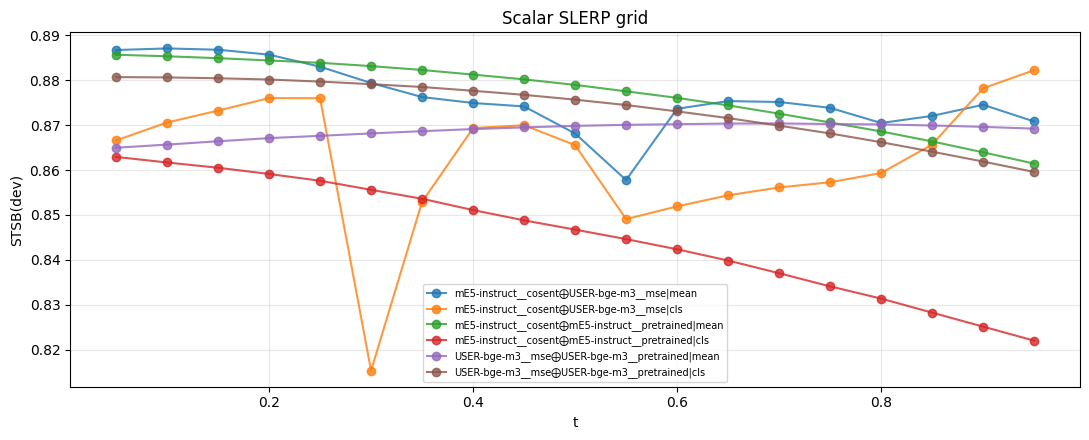

In [ ]:

fig, ax = plt.subplots(figsize=(11, 4.5))
for label, grid in slerp_curves.items():
    ts = sorted({t for (t, _) in grid})
    for pool_kind in ["mean", "cls"]:
        ys = [grid[(t, pool_kind)] for t in ts]
        ax.plot(ts, ys, marker="o", alpha=0.8, label=f"{label}|{pool_kind}")
ax.set_xlabel("t"); ax.set_ylabel(f"STSB({DEV})")
ax.set_title("Scalar SLERP grid"); ax.grid(alpha=0.3)
ax.legend(fontsize=7, loc="best")
plt.tight_layout(); plt.show()


## 9. Per-layer Evolutionary SLERP

Бюджет: 5 стартов × 50 итераций × 8 кандидатов = ~2000 dev-эвалов.

**Изменения от v1:**
- Стартовые `init_t ∈ [0.10, 0.20, 0.30, 0.40, 0.50]` (раньше было 0.3..0.7).
- Графики сохраняются как **два отдельных PNG**: сходимость и финальный t-вектор.
- В иерархический ансамбль попадает только результат с `rank_mean`.


In [ ]:

def layer_groups(sd_keys):
    groups = {}
    for k in sd_keys:
        if "encoder.layer." in k:
            n = k.split("encoder.layer.")[1].split(".")[0]
            grp = f"layer.{int(n):02d}"
        elif "embeddings" in k:
            grp = "embeddings"
        else:
            grp = "other"
        groups.setdefault(grp, []).append(k)
    return groups


def slerp_per_layer(sd1, sd2, t_vec: Dict[str, float]):
    common, _ = compatible_keys(sd1, sd2)
    grps = layer_groups(common)
    merged = {k: sd1[k].clone() for k in sd1}
    for g, keys in grps.items():
        t = float(t_vec.get(g, 0.5))
        for k in keys:
            v1, v2 = sd1[k], sd2[k]
            if v1.numel() <= 1:
                merged[k] = ((1-t)*v1.float() + t*v2.float()).to(v1.dtype)
            else:
                merged[k] = _slerp_vec(v1.float(), v2.float(), t)
    return merged


def evo_search_per_layer(a, b, spec, pool_kind, init_t,
                          n_iter=50, n_pop=8, sigma_init=0.08,
                          patience_shrink=5, patience_grow=10, seed=0):
    rng = np.random.RandomState(seed)
    common, _ = compatible_keys(SD[a], SD[b])
    grps = list(layer_groups(common).keys())

    best_t_vec = {g: init_t for g in grps}
    merged = slerp_per_layer(SD[a], SD[b], best_t_vec)
    enc = build_encoder_with_sd(spec, merged, pool_override=pool_kind)
    best_q = eval_on_dev(enc, use_prompt=False)
    cleanup(enc)
    history = [best_q]
    sigma = sigma_init
    no_improve = 0

    for it in range(1, n_iter+1):
        cands = []
        for _ in range(n_pop):
            c = {g: float(np.clip(best_t_vec[g] + rng.randn()*sigma, 0.02, 0.98))
                 for g in grps}
            cands.append(c)
        cands.append(dict(best_t_vec))   # elite

        scored = []
        for c in cands:
            merged = slerp_per_layer(SD[a], SD[b], c)
            enc = build_encoder_with_sd(spec, merged, pool_override=pool_kind)
            q = eval_on_dev(enc, use_prompt=False)
            cleanup(enc)
            scored.append((q, c))
        scored.sort(key=lambda x: -x[0])

        if scored[0][0] > best_q + 1e-6:
            best_q, best_t_vec = scored[0]
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience_shrink and sigma > 0.01:
            sigma *= 0.5; no_improve = 0
        elif no_improve >= patience_grow:
            sigma = min(sigma_init, sigma * 2.0); no_improve = 0

        history.append(best_q)
    return best_t_vec, best_q, history


# 5 стартов на новой сетке
INIT_TS = [0.20, 0.40, 0.80]
pair_evo = SLERP_PAIR
spec_evo = pick_spec_for_pair(*pair_evo)
pool_evo = slerp_rows[0]["best_pool"]
print(f"Evo-SLERP pair: {pair_evo[0]} ⨁ {pair_evo[1]}, pool={pool_evo}")
print(f"INIT_TS = {INIT_TS}")

all_evo_runs = []
for k, init_t in enumerate(INIT_TS):
    print(f"\n--- Evo run {k+1}/{len(INIT_TS)}: init_t={init_t} ---")
    t_vec, dev_q, history = evo_search_per_layer(
        pair_evo[0], pair_evo[1], spec_evo, pool_evo, init_t=init_t,
        n_iter=50, n_pop=8, sigma_init=0.08, seed=SEED + k,
    )
    print(f"  init_t={init_t}: final dev_q = {dev_q:.4f}")
    all_evo_runs.append({"init_t": init_t, "t_vec": t_vec,
                         "dev_q": dev_q, "history": history})

best_evo_run = max(all_evo_runs, key=lambda r: r["dev_q"])
print(f"\n=== Best Evo: init_t={best_evo_run['init_t']}, "
      f"dev_q={best_evo_run['dev_q']:.4f} ===")


In [ ]:

# Финальная оценка лучшего Evo
merged = slerp_per_layer(SD[pair_evo[0]], SD[pair_evo[1]], best_evo_run["t_vec"])
enc = build_encoder_with_sd(spec_evo, merged, pool_override=pool_evo)
evo_metrics = eval_on_test(enc, use_prompt=False)
evo_cos_stsb = get_pair_scores(enc, stsb["test"],  stsb_s1,  stsb_s2,  use_prompt=False)
evo_cos_22   = get_pair_scores(enc, sts22["test"], sts22_s1, sts22_s2, use_prompt=False)
cleanup(enc)

evo_row = {
    "model": f"Evo-SLERP-per-layer[{pair_evo[0]} ⨁ {pair_evo[1]}] "
             f"(init_t={best_evo_run['init_t']}, pool={pool_evo})",
    "type": "evo_slerp",
    "init_t": best_evo_run["init_t"], "dev_q": best_evo_run["dev_q"],
    **evo_metrics,
}
print(f"Evo-SLERP TEST: STSB={evo_metrics['STSB(test)']:.4f}  "
      f"STS22={evo_metrics['STS22(test)']:.4f}  Mean={evo_metrics['Mean']:.4f}")
print(f"Delta over scalar SLERP: "
      f"{(evo_metrics['Mean'] - slerp_rows[0]['Mean']):+.4f}")


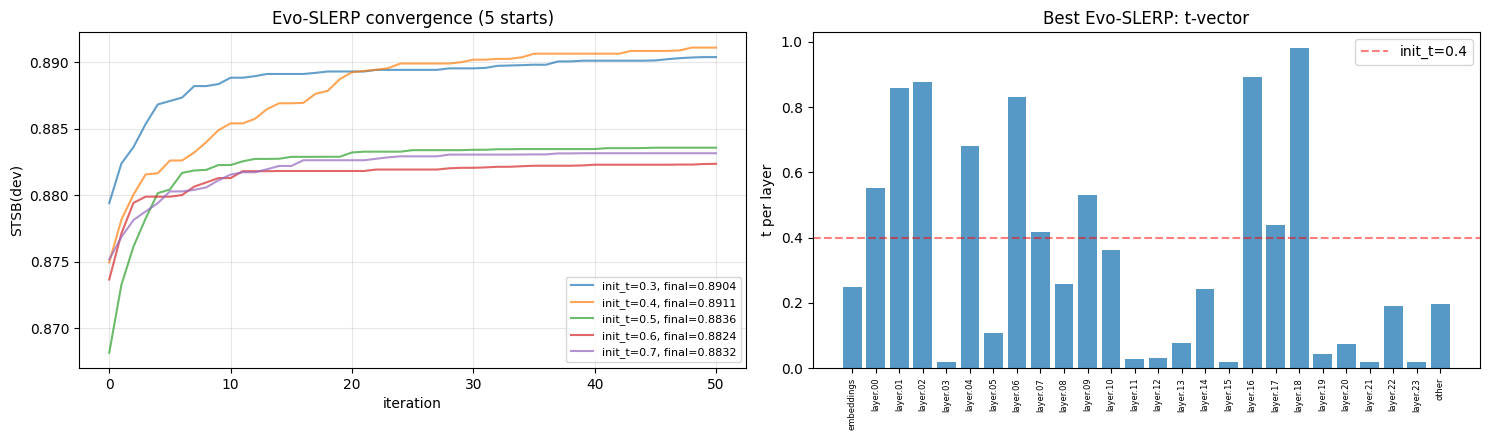

In [ ]:

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# (1) Сходимость 5 запусков
ax = axes[0]
for r in all_evo_runs:
    ax.plot(r["history"], alpha=0.7, label=f"init_t={r['init_t']}, "
            f"final={r['dev_q']:.4f}")
ax.set_xlabel("iteration"); ax.set_ylabel(f"STSB({DEV})")
ax.set_title("Evo-SLERP convergence (5 starts)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)

# (2) Распределение t по слоям лучшего запуска
ax = axes[1]
ts = []; labels = []
for g in sorted(best_evo_run["t_vec"].keys()):
    ts.append(best_evo_run["t_vec"][g]); labels.append(g)
ax.bar(range(len(ts)), ts, alpha=0.75)
ax.set_xticks(range(len(ts))); ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.axhline(best_evo_run["init_t"], color="red", linestyle="--", alpha=0.5,
           label=f"init_t={best_evo_run['init_t']}")
ax.set_ylabel("t per layer"); ax.set_title("Best Evo-SLERP: t-vector")
ax.legend()
plt.tight_layout(); plt.show()


## 10. LM-Cocktail

Формула:
$$M_r = \alpha M_t + (1 - \alpha) \sum_i w_i M_i, \qquad
w_i = \mathrm{softmax}(-L(M_i, E_t)/\tau)$$

Веса $w_i$ считаются автоматически через **CoSENT-loss** на 100 few-shot
примерах STSB-train.

Конфигурации:
- target = `USER-bge-m3__mse`, other = `mE5-instruct__cosent`,
- target = `mE5-instruct__cosent`, other = `USER-bge-m3__mse`,
- разные `α ∈ {0.3, 0.5, 0.7}`.


In [ ]:

def cosent_loss(z1, z2, scores, tau=20.0) -> float:
    cos = (z1 * z2).sum(-1)
    diff_cos = cos[:, None] - cos[None, :]
    diff_y   = scores[:, None] - scores[None, :]
    mask = (diff_y > 0)
    if mask.sum() == 0:
        return 0.0
    diff = -diff_cos[mask] * tau
    zero = torch.zeros(1, device=diff.device)
    return float(torch.logsumexp(torch.cat([zero, diff]), dim=0))


def few_shot_examples_from_stsb(n=100, seed=0):
    g = np.random.RandomState(seed)
    train = stsb["train"]
    idx = g.choice(len(train), size=min(n, len(train)), replace=False)
    s1, s2, y = [], [], []
    for i in idx:
        ex = train[int(i)]
        s1.append(ex[stsb_s1]); s2.append(ex[stsb_s2]); y.append(float(ex[stsb_y]))
    return s1, s2, torch.tensor(y, dtype=torch.float32)


def lmc_loss_for_sd(spec, sd, s1, s2, y_t, pool_kind="mean"):
    enc = build_encoder_with_sd(spec, sd, pool_override=pool_kind)
    e1 = enc.encode(s1, use_prompt=False).float()
    e2 = enc.encode(s2, use_prompt=False).float()
    cleanup(enc)
    return cosent_loss(e1, e2, y_t)


def lm_cocktail_merge(target_tag: str, other_tags: List[str], spec: ModelSpec,
                       alpha=0.5, tau=1.0, pool_kind="mean", n_few=100) -> dict:
    s1, s2, y_t = few_shot_examples_from_stsb(n=n_few, seed=42)
    losses = []
    for nm in other_tags:
        L = lmc_loss_for_sd(spec, SD[nm], s1, s2, y_t, pool_kind=pool_kind)
        losses.append(L)
        print(f"  CoSENT loss [{nm}] = {L:.4f}")
    L_arr = np.array(losses)
    z = -L_arr / tau; z -= z.max()
    w = np.exp(z); w = w / w.sum()
    print(f"  weights = {dict(zip(other_tags, w.round(4)))}")

    sd_t = SD[target_tag]
    common = set(sd_t.keys())
    for nm in other_tags:
        common &= set(SD[nm].keys())
    common = [k for k in sd_t.keys() if k in common
              and all(SD[nm][k].shape == sd_t[k].shape for nm in other_tags)]
    print(f"  common keys = {len(common)} / {len(sd_t)}")

    merged = {k: sd_t[k].clone() for k in sd_t.keys()}
    for k in common:
        base = alpha * sd_t[k].float()
        mix  = sum(w[i] * SD[other_tags[i]][k].float() for i in range(len(other_tags)))
        merged[k] = (base + (1-alpha)*mix).to(sd_t[k].dtype)
    return merged, w


In [ ]:

LMC_CONFIGS = [
    # (target, others, alpha, pool)
    ("USER-bge-m3__mse",     ["mE5-instruct__cosent"], 0.3, "cls"),
    ("USER-bge-m3__mse",     ["mE5-instruct__cosent"], 0.5, "cls"),
    ("USER-bge-m3__mse",     ["mE5-instruct__cosent"], 0.7, "cls"),
    ("USER-bge-m3__mse",     ["mE5-instruct__cosent"], 0.5, "mean"),
    ("mE5-instruct__cosent", ["USER-bge-m3__mse"],     0.3, "mean"),
    ("mE5-instruct__cosent", ["USER-bge-m3__mse"],     0.5, "mean"),
    ("mE5-instruct__cosent", ["USER-bge-m3__mse"],     0.7, "mean"),
]

lmc_rows = []
for target, others, alpha, pool_kind in LMC_CONFIGS:
    label = f"LMC[t={target}, o={'+'.join(others)}, α={alpha}, pool={pool_kind}]"
    print(f"\n=== {label} ===")
    try:
        spec_t = pick_spec_for_pair(target, others[0])
        merged, w = lm_cocktail_merge(target, others, spec_t, alpha=alpha,
                                       tau=1.0, pool_kind=pool_kind)
        enc = build_encoder_with_sd(spec_t, merged, pool_override=pool_kind)
        metrics = eval_on_test(enc, use_prompt=False)
        cleanup(enc)
        lmc_rows.append({"model": label, "type": "lm_cocktail",
                         "target": target, "alpha": alpha, "pool": pool_kind,
                         "weights": w.tolist(), **metrics})
        print(f"  TEST: STSB={metrics['STSB(test)']:.4f}  "
              f"STS22={metrics['STS22(test)']:.4f}  Mean={metrics['Mean']:.4f}")
    except Exception as e:
        print(f"  ⚠️  failed: {type(e).__name__}: {e}")

df_lmc = pd.DataFrame(lmc_rows)[["model", "STSB(test)", "STS22(test)", "Mean"]] \
    if lmc_rows else pd.DataFrame()
df_lmc


## 11. Иерархический ансамбль (rank_mean)

Главный практический сценарий: **пара `Qwen + Evo-SLERP(mE5+BGE)`**.
- Qwen — самая сильная одиночная модель.
- Evo-SLERP — слитая XLM-R-модель (мE5 + BGE в одном чекпоинте).

Сравниваем с другими парными вариантами `Qwen + одна_из_XLM-R` чтобы понять,
насколько Evo-SLERP лучше использования одной из исходных XLM-R-моделей.

Также — иерархический ансамбль на 4 моделях (Qwen + 2 XLM-R + Evo-SLERP) как
полный комбайн.


In [ ]:

hier_rows = []
qwen_tag = next(t for t in scores_stsb if "Qwen" in t)

evo_label = f"Evo-SLERP[{pair_evo[0]}⨁{pair_evo[1]}]"

# (a) Парный Qwen + Evo-SLERP  (главный сценарий)
pair_stsb = {qwen_tag: scores_stsb[qwen_tag], evo_label: evo_cos_stsb}
pair_22   = {qwen_tag: scores_22[qwen_tag],   evo_label: evo_cos_22}
p1 = ensemble_scores(pair_stsb, "rank_mean")
p2 = ensemble_scores(pair_22,   "rank_mean")
q1, q2 = sts_quality(y_stsb, p1), sts_quality(y_22, p2)
row = {"model": f"Hier2[{qwen_tag} + {evo_label}] (rank_mean)",
       "type": "hier2_rank_mean",
       "STSB(test)": q1, "STS22(test)": q2, "Mean": (q1+q2)/2}
hier_rows.append(row)
print(f"  Hier2 (Qwen + Evo-SLERP, rank_mean):")
print(f"    STSB={q1:.4f}  STS22={q2:.4f}  Mean={row['Mean']:.4f}")

# (b) Контрольные парные: Qwen + одна_исходная_XLM-R (вместо Evo-SLERP)
for other in [t for t in scores_stsb if t != qwen_tag]:
    pair_stsb = {qwen_tag: scores_stsb[qwen_tag], other: scores_stsb[other]}
    pair_22   = {qwen_tag: scores_22[qwen_tag],   other: scores_22[other]}
    p1 = ensemble_scores(pair_stsb, "rank_mean")
    p2 = ensemble_scores(pair_22,   "rank_mean")
    q1, q2 = sts_quality(y_stsb, p1), sts_quality(y_22, p2)
    row = {"model": f"Hier2[{qwen_tag} + {other}] (rank_mean)",
           "type": "hier2_rank_mean_ctrl",
           "STSB(test)": q1, "STS22(test)": q2, "Mean": (q1+q2)/2}
    hier_rows.append(row)
    print(f"  Hier2 (Qwen + {other}):  Mean={row['Mean']:.4f}")

# (c) Полный иерархический: 3 baseline + Evo-SLERP (rank_mean)
hier_full_stsb = dict(scores_stsb); hier_full_stsb[evo_label] = evo_cos_stsb
hier_full_22   = dict(scores_22);   hier_full_22[evo_label]   = evo_cos_22
p1 = ensemble_scores(hier_full_stsb, "rank_mean")
p2 = ensemble_scores(hier_full_22,   "rank_mean")
q1, q2 = sts_quality(y_stsb, p1), sts_quality(y_22, p2)
row = {"model": f"Hier4[{'+'.join(hier_full_stsb.keys())}] (rank_mean)",
       "type": "hier4_rank_mean",
       "STSB(test)": q1, "STS22(test)": q2, "Mean": (q1+q2)/2}
hier_rows.append(row)
print(f"\n  Hier4 (всё вместе, rank_mean):")
print(f"    STSB={q1:.4f}  STS22={q2:.4f}  Mean={row['Mean']:.4f}")

df_hier = pd.DataFrame(hier_rows).sort_values("Mean", ascending=False)
df_hier


  Hier2 (Qwen + Evo-SLERP, rank_mean):
    STSB=0.8837  STS22=0.7090  Mean=0.7964
  Hier2 (Qwen + mE5-instruct__cosent):  Mean=0.7974
  Hier2 (Qwen + USER-bge-m3__mse):  Mean=0.7928

  Hier4 (всё вместе, rank_mean):
    STSB=0.8775  STS22=0.7089  Mean=0.7932


,model,type,STSB(test),STS22(test),Mean
1,Hier2[Qwen3-Emb-8B__cosent + mE5-instruct__cos...,hier2_rank_mean_ctrl,0.884502,0.710232,0.797367
0,Hier2[Qwen3-Emb-8B__cosent + Evo-SLERP[mE5-ins...,hier2_rank_mean,0.883739,0.709016,0.796377
3,Hier4[mE5-instruct__cosent+USER-bge-m3__mse+Qw...,hier4_rank_mean,0.877489,0.708870,0.793180
2,Hier2[Qwen3-Emb-8B__cosent + USER-bge-m3__mse]...,hier2_rank_mean_ctrl,0.884937,0.700570,0.792754


## 12. Финальная сводка

In [ ]:

all_rows = baseline_rows + ensemble_rows + slerp_rows + [evo_row] + lmc_rows + hier_rows

df_final = pd.DataFrame(all_rows)
keep = ["model", "type", "STSB(test)", "STS22(test)", "Mean"]
for c in keep:
    if c not in df_final.columns:
        df_final[c] = np.nan
df_final = df_final[keep].sort_values("Mean", ascending=False).reset_index(drop=True)

qwen_mean = next((r["Mean"] for r in baseline_rows if "Qwen" in r["model"]), None)
print(f"\n=== Qwen baseline: Mean = {qwen_mean:.4f} ===\n")

print("ТОП-20:")
print(df_final.head(20).to_string(index=False))

print("\n=== Лучшее в каждой категории (с указанием параметров) ===")
def find_best(filter_types: list, label: str):
    subset = df_final[df_final["type"].isin(filter_types)]
    if not len(subset):
        print(f"  {label}: -"); return None
    r = subset.iloc[0]
    delta = r["Mean"] - qwen_mean if qwen_mean else 0
    print(f"  {label}:")
    print(f"    {r['model']}")
    print(f"    STSB={r['STSB(test)']:.4f}  STS22={r['STS22(test)']:.4f}  "
          f"Mean={r['Mean']:.4f}  (Δ Qwen: {delta:+.4f})")
    return r

best_base   = find_best(["baseline_lora"],         "Best baseline (one LoRA-checkpoint)")
best_ens    = find_best(["ens3_simple","ens3_zmean","ens3_rank_mean",
                          "ens2_rank_mean"],         "Best score ensemble")
best_slerp  = find_best(["slerp_scalar"],          "Best scalar SLERP")
best_evo    = find_best(["evo_slerp"],             "Best Evo-SLERP")
best_lmc    = find_best(["lm_cocktail"],           "Best LM-Cocktail")
best_hier   = find_best(["hier2_rank_mean","hier4_rank_mean"], "Best Hierarchical")



=== Qwen baseline: Mean = 0.7909 ===

ТОП-20:
                                                                                                                         model                 type  STSB(test)  STS22(test)     Mean
                                                       Ensemble2[('mE5-instruct__cosent', 'Qwen3-Emb-8B__cosent')] (rank_mean)       ens2_rank_mean    0.884502     0.710232 0.797367
                                                                Hier2[Qwen3-Emb-8B__cosent + mE5-instruct__cosent] (rank_mean) hier2_rank_mean_ctrl    0.884502     0.710232 0.797367
                                    Hier2[Qwen3-Emb-8B__cosent + Evo-SLERP[mE5-instruct__cosent⨁USER-bge-m3__mse]] (rank_mean)      hier2_rank_mean    0.883739     0.709016 0.796377
                                             Ensemble3[mE5-instruct__cosent+USER-bge-m3__mse+Qwen3-Emb-8B__cosent] (rank_mean)       ens3_rank_mean    0.881331     0.707421 0.794376
                                           

  saved: plots/final_leaderboard_top20.png


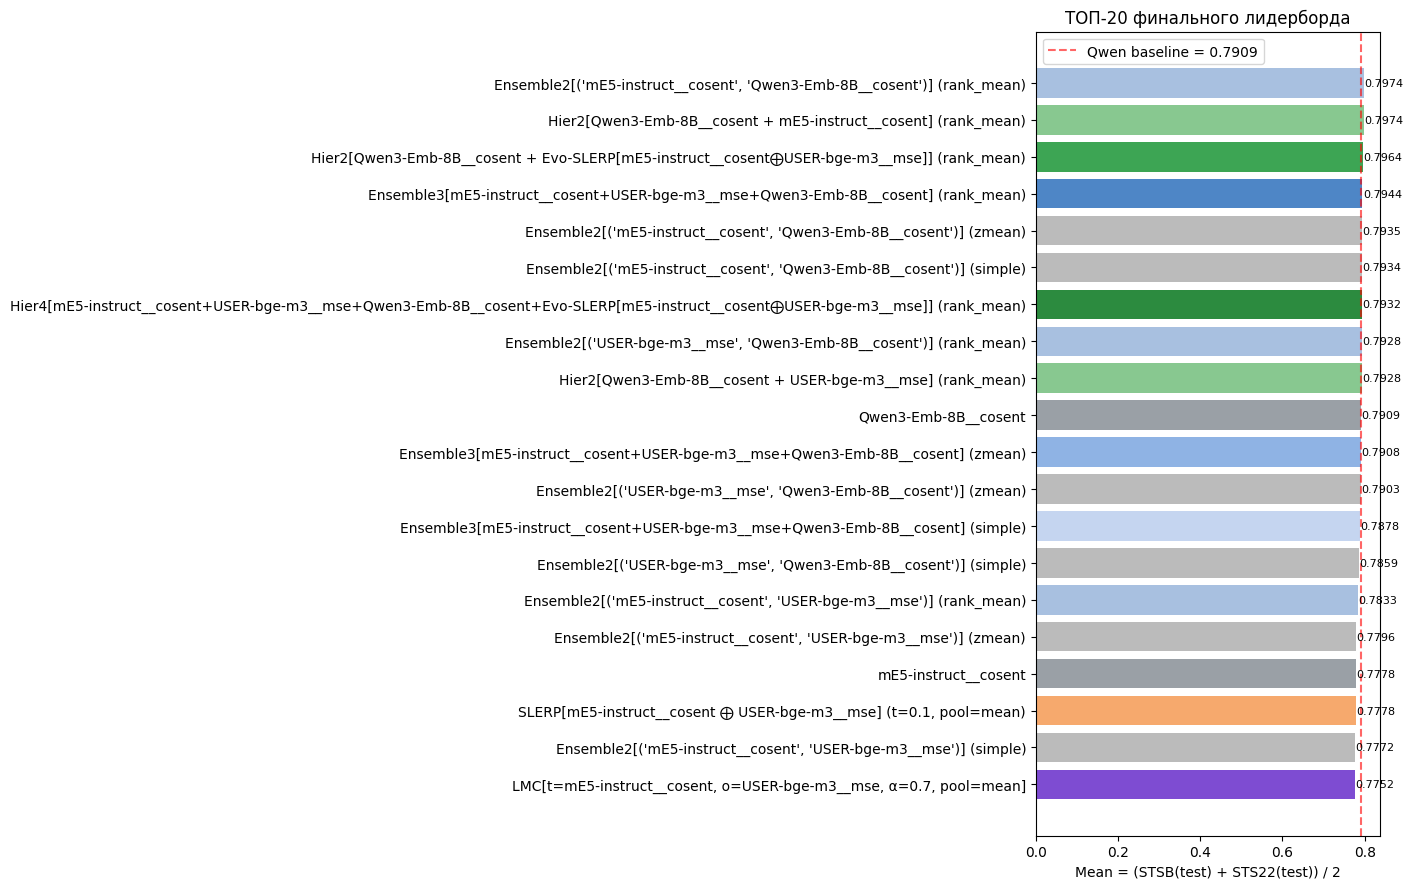

In [ ]:

# Финальный bar plot — ТОП-20 с красной линией Qwen-baseline
type_color = {
    "baseline_lora": "#9aa0a6",
    "ens2_rank_mean": "#a8c0e0",
    "ens3_simple": "#c5d5f0",
    "ens3_zmean": "#8fb3e4",
    "ens3_rank_mean": "#4e86c6",
    "slerp_scalar": "#f6a96d",
    "evo_slerp": "#ed8a3c",
    "lm_cocktail": "#7e4cd2",
    "hier2_rank_mean": "#3da554",
    "hier2_rank_mean_ctrl": "#88c890",
    "hier4_rank_mean": "#2c8b3f",
}
top = df_final.head(20)
colors = [type_color.get(t, "#bbbbbb") for t in top["type"]]
fig, ax = plt.subplots(figsize=(14, max(7, 0.45*len(top))))
ax.barh(top["model"][::-1], top["Mean"][::-1], color=colors[::-1])
ax.axvline(qwen_mean, color="red", linestyle="--", alpha=0.6,
           label=f"Qwen baseline = {qwen_mean:.4f}")
ax.set_xlabel("Mean = (STSB(test) + STS22(test)) / 2")
ax.set_title("ТОП-20 финального лидерборда")
for i, (_, v) in enumerate(zip(top["model"][::-1], top["Mean"][::-1])):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)
ax.legend()
plt.tight_layout()
path_final = PLOTS_DIR / "final_leaderboard_top20.png"
plt.savefig(path_final, dpi=150, bbox_inches="tight")
print(f"  saved: {path_final}")
plt.show()
